In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

In [2]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


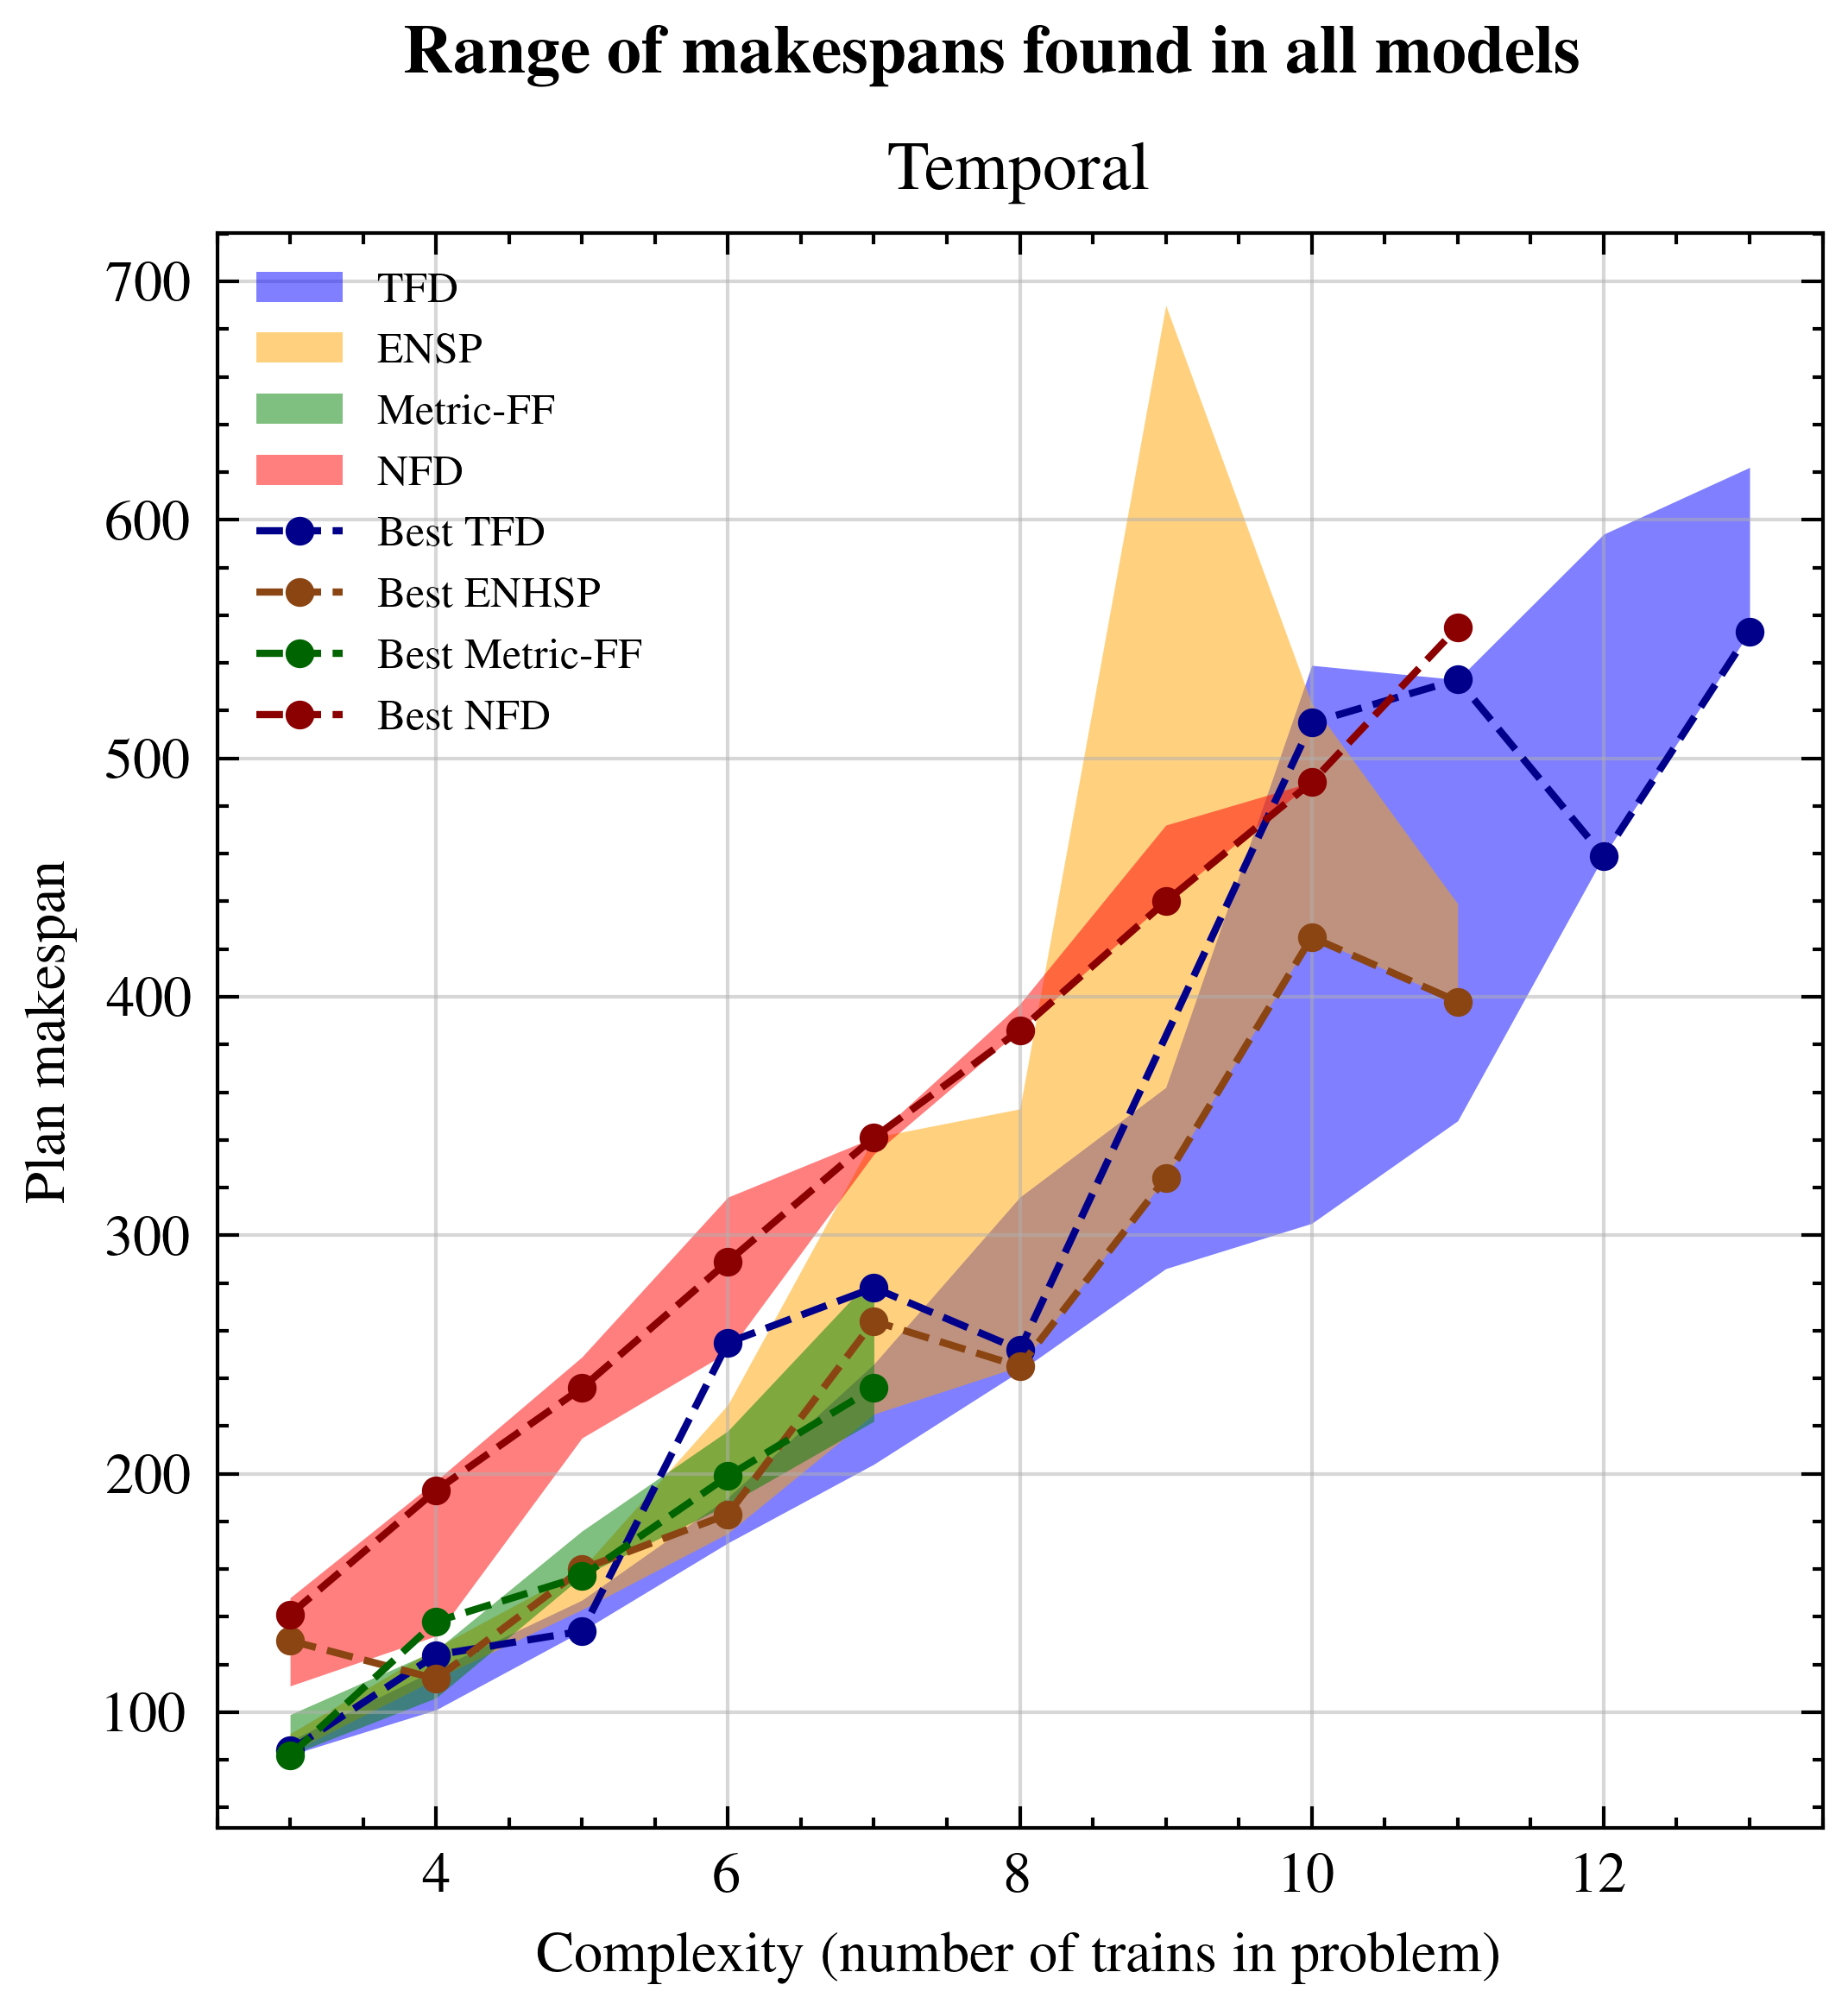

In [19]:
tfd_y1, tfd_y2 = [], []
enhsp_y1, enhsp_y2 = [], []
metricff_y1, metricff_y2 = [], []
nfd_y1, nfd_y2 = [], []
tfd_x = []
enhsp_x = []
metricff_x = []
nfd_x = []

for i in range(3,20):
    df_tfd_filt = df_tfd.query(f"num_trains=={i}")
    tfd_makespans = sorted(df_tfd_filt['makespan_pp'])
    max_idx = min(len(tfd_makespans)-1,6)
    if len(tfd_makespans)> 0:
        tfd_y1.append(tfd_makespans[0])
        tfd_y2.append(tfd_makespans[max_idx])
        tfd_x.append(i)

    df_enhsp_filt = df_enhsp.query(f"num_trains=={i}")
    enhsp_makespans = sorted(df_enhsp_filt['makespan_pp'])
    max_idx = min(len(enhsp_makespans)-1,6)
    if len(enhsp_makespans)> 0:
        enhsp_y1.append(enhsp_makespans[0])
        enhsp_y2.append(enhsp_makespans[max_idx])
        enhsp_x.append(i)

    df_metricff_filt = df_mff.query(f"num_trains=={i}")
    metricff_makespans = sorted(df_metricff_filt['makespan_pp'])
    max_idx = min(len(metricff_makespans)-1,6)
    if len(metricff_makespans)> 0:
        metricff_y1.append(metricff_makespans[0])
        metricff_y2.append(metricff_makespans[max_idx])
        metricff_x.append(i)

    df_nfd_filt = df_nfd.query(f"num_trains=={i}")
    nfd_makespans = sorted(df_nfd_filt['makespan_pp'])
    max_idx = min(len(nfd_makespans)-1,6)
    if len(nfd_makespans)> 0:
        nfd_y1.append(nfd_makespans[0])
        nfd_y2.append(nfd_makespans[max_idx])
        nfd_x.append(i)

df_best_tfd = df_tfd.query('planner=="tfd" and base=="base1" and config==11')
df_best_enhsp = df_enhsp.query('planner=="enhsp" and base=="base3" and config==6')
df_best_metricff = df_mff.query('planner=="metricff" and base=="base3" and config==5')
df_best_nfd = df_nfd.query('planner=="nfd" and config==9')

plt.style.use(['ieee', 'science'])

fig, ax = plt.subplots(figsize=(4,4), sharex=True, sharey=True)
fig.suptitle(r"""\textbf{Range of makespans found in all models}""")
ax.set_title('Temporal')
ax.fill_between(tfd_x, tfd_y1, tfd_y2, alpha=0.5, linewidth=0, label='TFD', color='blue')
ax.fill_between(enhsp_x, enhsp_y1, enhsp_y2, alpha=0.5, linewidth=0, label='ENSP', color='orange')
ax.fill_between(metricff_x, metricff_y1, metricff_y2, alpha=0.5, linewidth=0, label='Metric-FF', color='green')
ax.fill_between(nfd_x, nfd_y1, nfd_y2, alpha=0.5, linewidth=0, label='NFD', color='red')
ax.plot(df_best_tfd['num_trains'], df_best_tfd['makespan_pp'], '.--', label='Best TFD', color='darkblue')
ax.plot(df_best_enhsp['num_trains'], df_best_enhsp['makespan_pp'], '.--', label='Best ENHSP', color='saddlebrown')
ax.plot(df_best_metricff['num_trains'], df_best_metricff['makespan_pp'], '.--', label='Best Metric-FF', color='darkgreen')
ax.plot(df_best_nfd['num_trains'], df_best_nfd['makespan_pp'], '.--', label='Best NFD', color='darkred')
ax.grid(True, alpha=0.5)
ax.set_ylabel('Plan makespan')
ax.set_xlabel('Complexity (number of trains in problem)')
ax.legend(loc='upper left', fontsize=6)
# ax.set_yscale('log')

fig.savefig('compare_planners.png')